## Setup

In [1]:
# Configure loguru FIRST to suppress verbose logging in notebooks only
import sys
import os
from loguru import logger
logger.remove()  # Remove default handler

# Add filter to suppress tech_adoption warnings
def filter_tech_warnings(record):
    return not any(msg in record["message"] for msg in [
        "No data found for technology",
        "No growth data available"
    ])

logger.add(sys.stderr, level='WARNING', format='<level>{level: <8}</level> | <cyan>{name}</cyan>:<cyan>{function}</cyan>:<cyan>{line}</cyan> - <level>{message}</level>', filter=filter_tech_warnings)

from pathlib import Path

# Get the BICEP root directory (three levels up from this notebook)
bicep_root = Path.cwd().parent.parent.parent
if str(bicep_root) not in sys.path:
    sys.path.insert(0, str(bicep_root))

import pandas as pd
import numpy as np
from scipy import stats

from bicep.analysis import BicepResults, BicepMultiStateResults

print("Environment setup complete!")

Environment setup complete!


In [2]:
import os

# SUPPRESS LOGGING FOR CLEAN NOTEBOOK OUTPUT
# To see full BICEP logging details, comment out the line below:
os.environ['LOGURU_LEVEL'] = 'WARNING'

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm, invweibull, lognorm, gaussian_kde

plt.rcParams['figure.dpi'] = 150

print("Plotting libraries loaded!")

Plotting libraries loaded!


## Why Use Distributions?

Infrastructure costs vary based on:

1. **Building characteristics** - Size, age, existing equipment
2. **Regional variations** - Labor costs, material prices
3. **Technical factors** - Complexity of upgrades, site conditions
4. **Market factors** - Supply chain, contractor availability

Instead of using a single cost estimate, BICEP uses probability distributions to capture this uncertainty.

## Built-in Distributions in BICEP

BICEP's `utils.sampling` module provides several distribution classes, each with a `plot_distribution()` method for quick visualization. Below we recreate these distributions directly (without requiring the Azure data connection) and visualize them using the same approach as `BaseDistribution.plot_distribution()`.

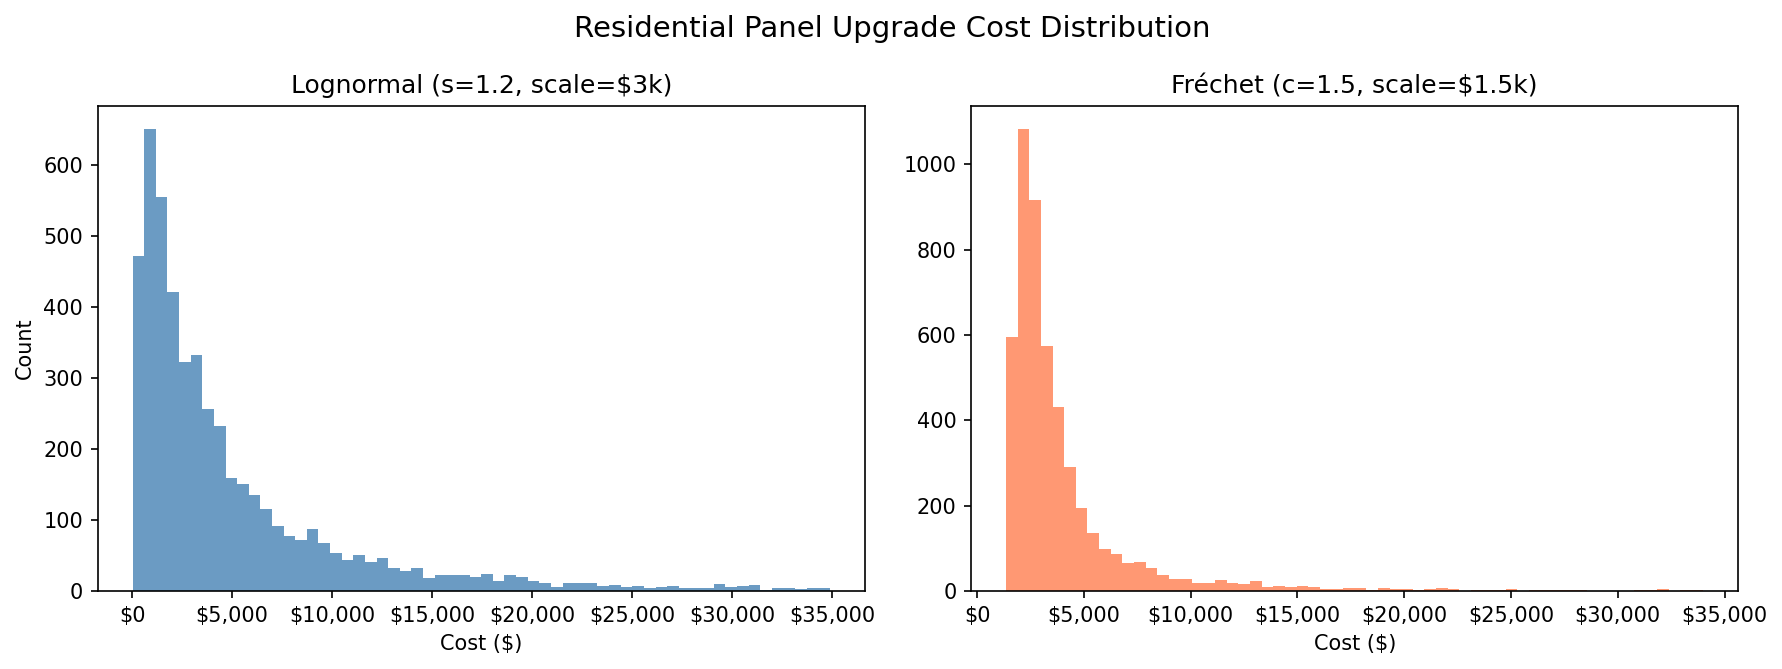

In [4]:
# ── Residential Panel Upgrade Cost: Lognormal vs Fréchet ──────────────
# From PanelUpgradeCostDistribution in utils/sampling.py

# Lognormal: shape=1.2, scale=3000
res_lognorm = lognorm(s=1.2, scale=3000, loc=0)
res_lognorm_samples = res_lognorm.rvs(5000)
res_lognorm_samples = res_lognorm_samples[(res_lognorm_samples >= 0) & (res_lognorm_samples <= 35000)]

# Fréchet (Inverse Weibull): c=1.5, scale=1500, loc=1000
res_frechet = invweibull(c=1.5, scale=1500, loc=1000)
res_frechet_samples = res_frechet.rvs(5000)
res_frechet_samples = res_frechet_samples[(res_frechet_samples >= 0) & (res_frechet_samples <= 35000)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Residential Panel Upgrade Cost Distribution", fontsize=14)

ax1.hist(res_lognorm_samples, bins=60, color='steelblue', alpha=0.8)
ax1.set_title("Lognormal (s=1.2, scale=$3k)")
ax1.set_xlabel("Cost ($)")
ax1.set_ylabel("Count")
ax1.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

ax2.hist(res_frechet_samples, bins=60, color='coral', alpha=0.8)
ax2.set_title("Fréchet (c=1.5, scale=$1.5k)")
ax2.set_xlabel("Cost ($)")
ax2.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

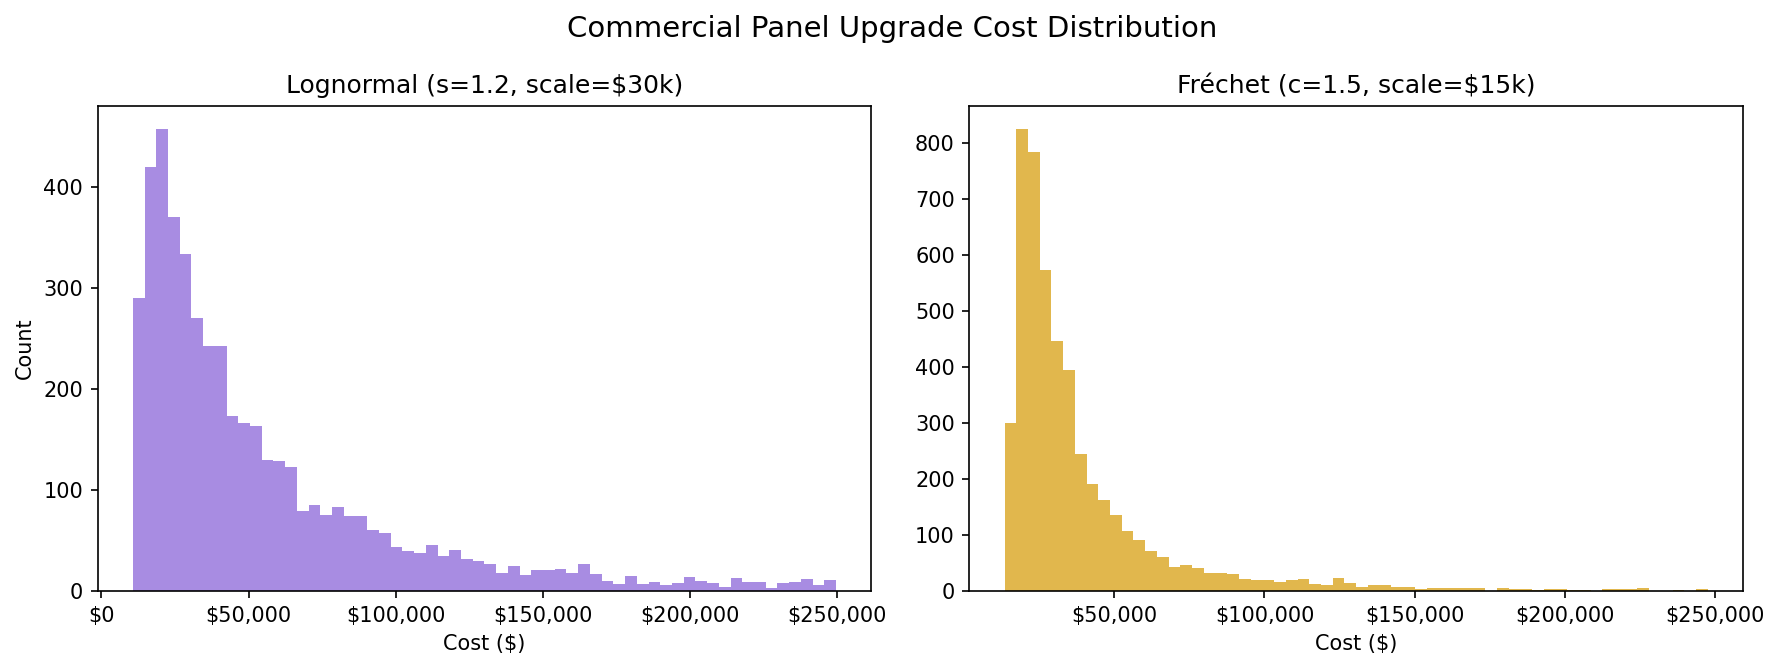

In [5]:
# ── Commercial Panel Upgrade Cost: Lognormal vs Fréchet ──────────────
# From PanelUpgradeCostDistribution(residential=False) in utils/sampling.py

# Lognormal: shape=1.2, scale=30000, loc=10000
com_lognorm = lognorm(s=1.2, scale=30000, loc=10000)
com_lognorm_samples = com_lognorm.rvs(5000)
com_lognorm_samples = com_lognorm_samples[(com_lognorm_samples >= 0) & (com_lognorm_samples <= 250000)]

# Fréchet: c=1.5, scale=15000, loc=10000
com_frechet = invweibull(c=1.5, scale=15000, loc=10000)
com_frechet_samples = com_frechet.rvs(5000)
com_frechet_samples = com_frechet_samples[(com_frechet_samples >= 0) & (com_frechet_samples <= 250000)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fig.suptitle("Commercial Panel Upgrade Cost Distribution", fontsize=14)

ax1.hist(com_lognorm_samples, bins=60, color='mediumpurple', alpha=0.8)
ax1.set_title("Lognormal (s=1.2, scale=$30k)")
ax1.set_xlabel("Cost ($)")
ax1.set_ylabel("Count")
ax1.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

ax2.hist(com_frechet_samples, bins=60, color='goldenrod', alpha=0.8)
ax2.set_title("Fréchet (c=1.5, scale=$15k)")
ax2.set_xlabel("Cost ($)")
ax2.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

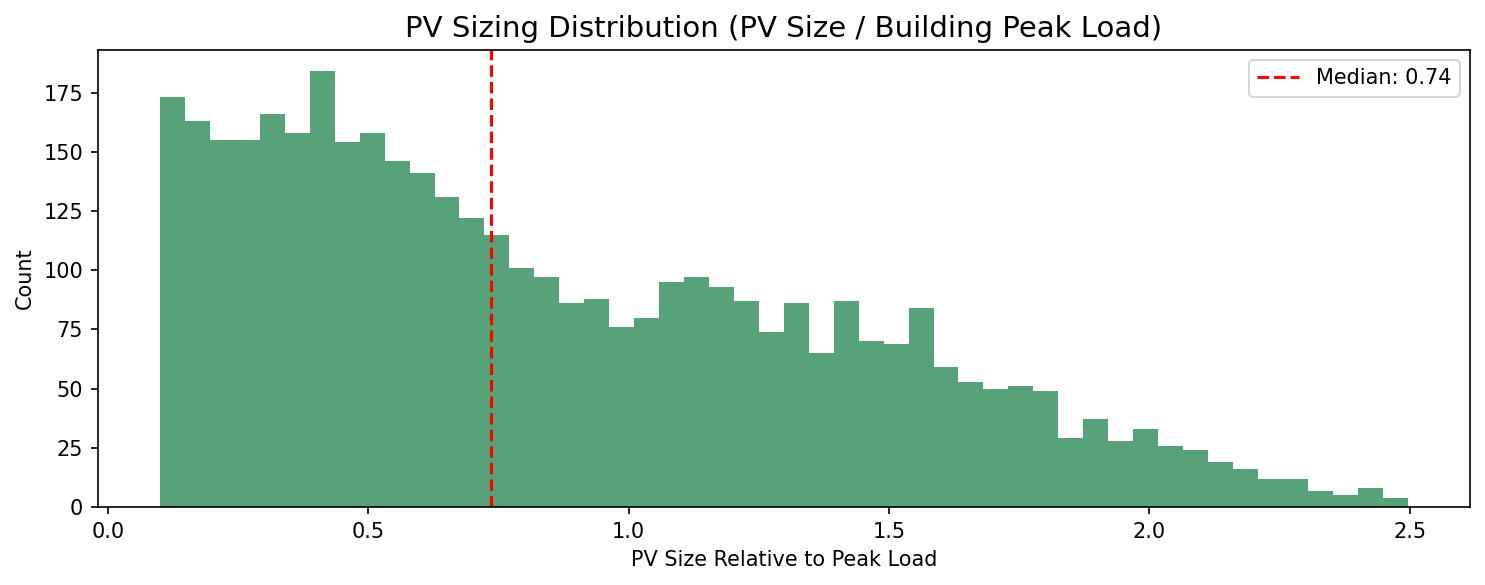

In [6]:
# ── PV Sizing Distribution ────────────────────────────────────────────
# From PvSizingDistribution in utils/sampling.py
# Based on NREL/TP-6A20-64793: PV size relative to building peak load

nrel_data = [0.16139, 0.17360, 0.19603, 0.19938, 0.26415, 0.30769, 0.38235,
             0.38346, 0.54924, 0.75204, 1.13462, 1.13978, 1.36842, 1.38415, 1.95833]

pv_kde = gaussian_kde(nrel_data)
pv_samples = pv_kde.resample(5000).flatten()
pv_samples = pv_samples[(pv_samples >= 0.1) & (pv_samples <= 2.5)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pv_samples, bins=50, color='seagreen', alpha=0.8)
ax.set_title('PV Sizing Distribution (PV Size / Building Peak Load)', fontsize=14)
ax.set_xlabel('PV Size Relative to Peak Load')
ax.set_ylabel('Count')
ax.axvline(np.median(pv_samples), color='red', linestyle='--',
           label=f"Median: {np.median(pv_samples):.2f}")
ax.legend()
plt.tight_layout()
plt.show()

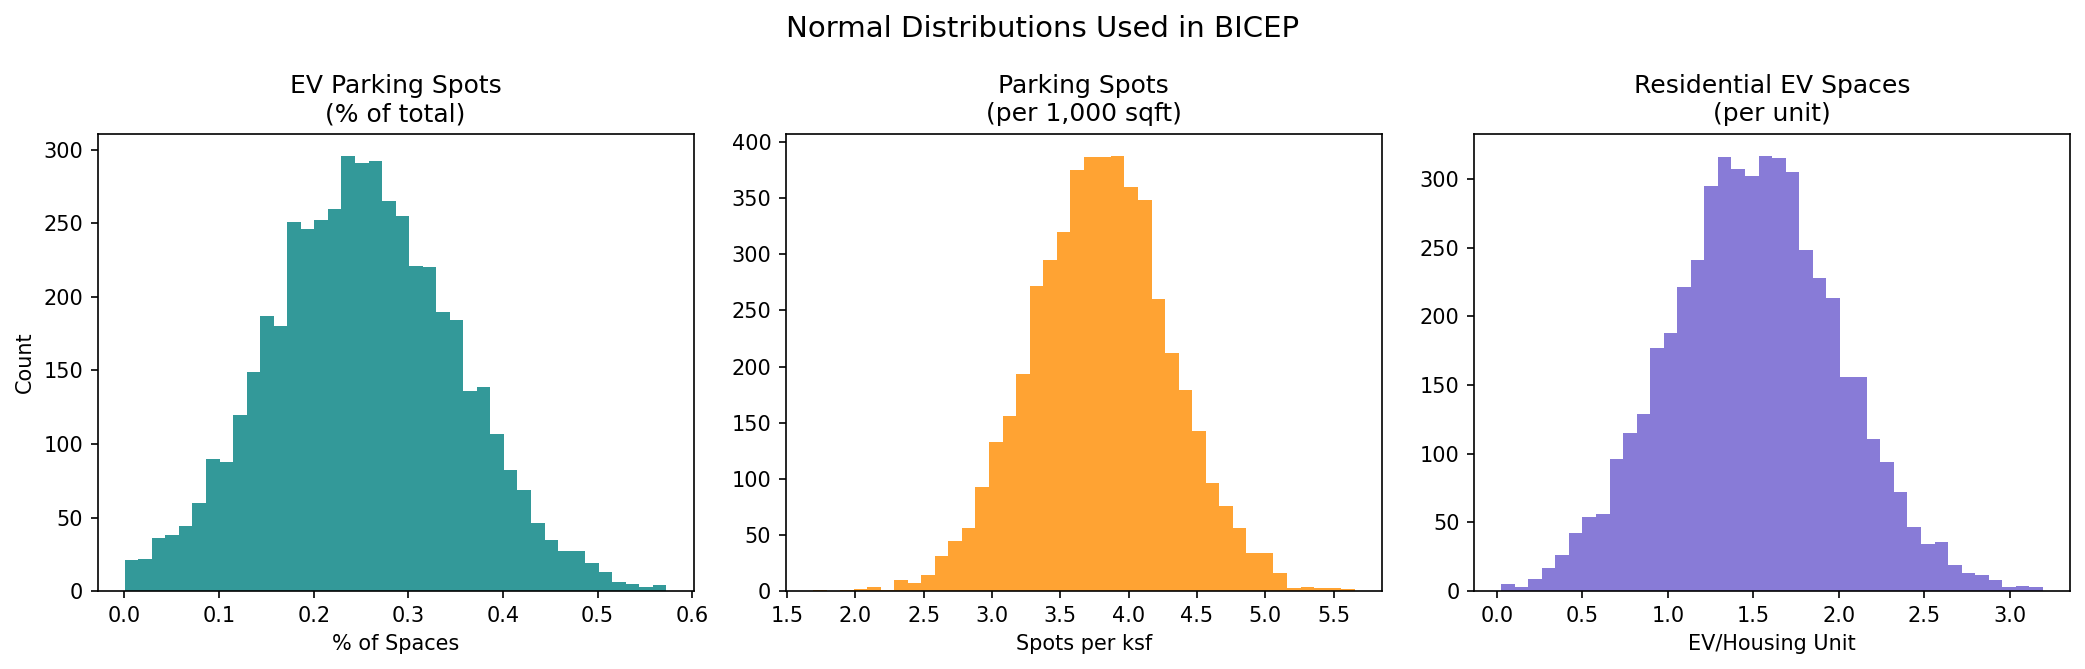

In [7]:
# ── EV, Parking, and Residential EV Distributions ────────────────────
# From EvSpotsDistribution, ParkingSpotsDistribution, ResidentialEvDistribution

ev_spots_dist = norm(loc=0.25, scale=0.1)
parking_dist = norm(loc=3.8, scale=0.5)
res_ev_dist = norm(loc=1.5, scale=0.5)

ev_samples = ev_spots_dist.rvs(5000)
ev_samples = ev_samples[ev_samples >= 0]
parking_samples = parking_dist.rvs(5000)
parking_samples = parking_samples[parking_samples >= 0]
res_ev_samples = res_ev_dist.rvs(5000)
res_ev_samples = res_ev_samples[res_ev_samples >= 0]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("Normal Distributions Used in BICEP", fontsize=14)

ax1.hist(ev_samples, bins=40, color='teal', alpha=0.8)
ax1.set_title("EV Parking Spots\n(% of total)")
ax1.set_xlabel("% of Spaces")
ax1.set_ylabel("Count")

ax2.hist(parking_samples, bins=40, color='darkorange', alpha=0.8)
ax2.set_title("Parking Spots\n(per 1,000 sqft)")
ax2.set_xlabel("Spots per ksf")

ax3.hist(res_ev_samples, bins=40, color='slateblue', alpha=0.8)
ax3.set_title("Residential EV Spaces\n(per unit)")
ax3.set_xlabel("EV/Housing Unit")

plt.tight_layout()
plt.show()

### Summary of All BICEP Distributions

The table below summarizes the built-in distribution classes from `utils.sampling`. Each class provides a `plot_distribution()` method (demonstrated above) and a `constrained_samples()` method for generating bounded random samples.

| Distribution Class | Type | Parameters | Use Case |
|---|---|---|---|
| `PanelUpgradeCostDistribution` (residential) | Lognormal / Fréchet | shape=1.2, scale=\$3,000 | Residential panel upgrade costs |
| `PanelUpgradeCostDistribution` (commercial) | Lognormal / Fréchet | shape=1.2, scale=\$30,000 | Commercial panel upgrade costs |
| `PvSizingDistribution` | KDE (empirical) | NREL data | PV system sizing relative to peak load |
| `EvSpotsDistribution` | Normal | μ=25%, σ=10% | Fraction of parking for EV charging |
| `ParkingSpotsDistribution` | Normal | μ=3.8, σ=0.5 spots/ksf | Total parking spots per building |
| `ResidentialEvDistribution` | Normal | μ=1.5, σ=0.5 EV/unit | Residential EV spaces per housing unit |
| `PanelUtilizationDistribution` | KDE (empirical) | HEA panel data | Panel utilization (peak load / capacity) |

### 1. Panel Utilization Distribution

Represents how fully existing electrical panels are utilized.

In [8]:
# Run High scenario from SQLite database (not intermediate CSV files)
print("Running High scenario analysis for all US states...")
print("(This may take a few minutes as it processes each state separately)\n")

high_all = BicepMultiStateResults(scenario='high', mode='local', target_states='all')
results = high_all.all_states_buildings

print(f"Loaded {len(results):,} buildings\n")

# Analyze the cost distribution across buildings
print("Cost Distribution Statistics (All Buildings):")
print(f"  Mean: ${results['weighted_cost'].mean():,.0f}")
print(f"  Median: ${results['weighted_cost'].median():,.0f}")
print(f"  Std Dev: ${results['weighted_cost'].std():,.0f}")
print(f"  Min: ${results['weighted_cost'].min():,.0f}")
print(f"  Max: ${results['weighted_cost'].max():,.0f}")
print(f"  25th percentile: ${results['weighted_cost'].quantile(0.25):,.0f}")
print(f"  75th percentile: ${results['weighted_cost'].quantile(0.75):,.0f}")

Running High scenario analysis for all US states...
(This may take a few minutes as it processes each state separately)



/Users/faye994/code/BICEP/bicep/capacity.py:329: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg['represented_vehicles'] = (bldg['total_units']/5).fillna(1) * bldg['total_parking_spaces']


/Users/faye994/code/BICEP/bicep/capacity.py:329: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bldg['represented_vehicles'] = (bldg['total_units']/5).fillna(1) * bldg['total_parking_spaces']


Loaded 884,596 buildings

Cost Distribution Statistics (All Buildings):
  Mean: $50,381
  Median: $24,525
  Std Dev: $68,020
  Min: $99
  Max: $507,533
  25th percentile: $9,814
  75th percentile: $60,622


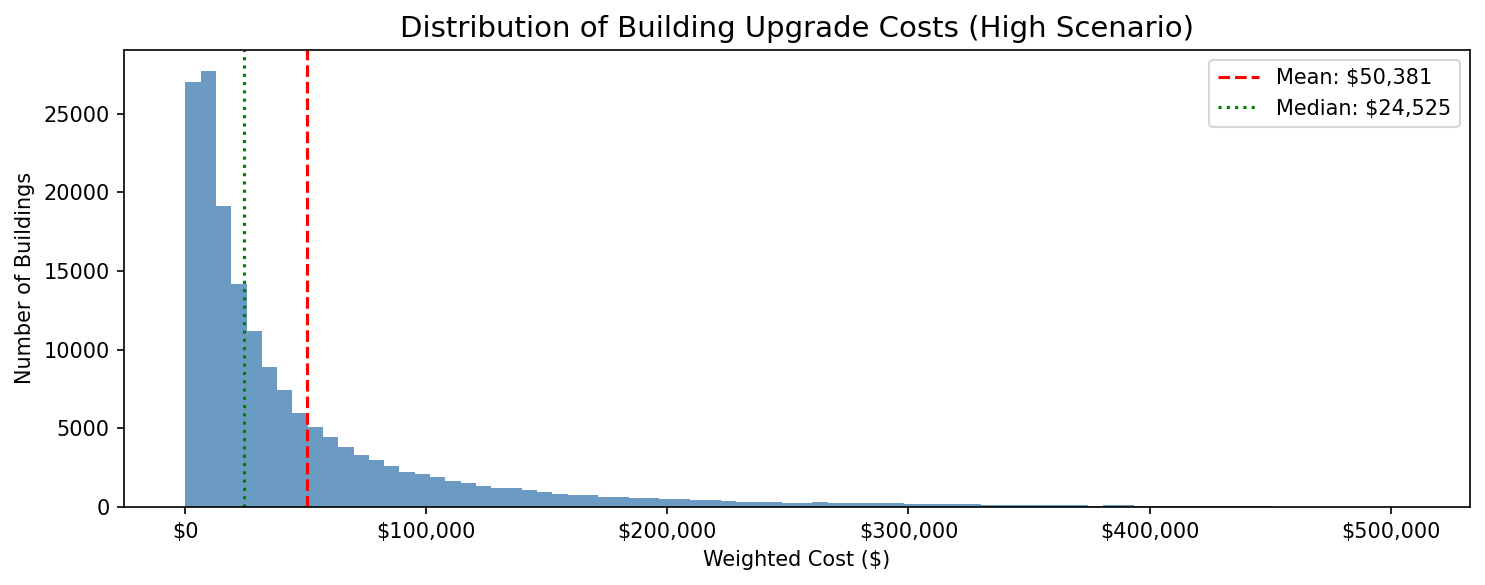

In [9]:
# Visualize the overall cost distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(results['weighted_cost'], bins=80, color='steelblue', alpha=0.8)
ax.axvline(results['weighted_cost'].mean(), color='red', linestyle='--',
           label=f"Mean: ${results['weighted_cost'].mean():,.0f}")
ax.axvline(results['weighted_cost'].median(), color='green', linestyle=':',
           label=f"Median: ${results['weighted_cost'].median():,.0f}")
ax.set_title('Distribution of Building Upgrade Costs (High Scenario)', fontsize=14)
ax.set_xlabel('Weighted Cost ($)')
ax.set_ylabel('Number of Buildings')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

### 2. PV Sizing Distribution

Represents the relationship between building loads and solar PV system size.

In [10]:
# Analyze cost distribution by residential vs commercial
print("\n" + "="*70)
print("COST DISTRIBUTION BY BUILDING TYPE")
print("="*70)

residential = results[results['residential'] == 1]
commercial = results[results['residential'] == 0]

print(f"\nResidential ({len(residential):,} buildings):")
print(f"  Mean cost: ${residential['weighted_cost'].mean():,.0f}")
print(f"  Median cost: ${residential['weighted_cost'].median():,.0f}")
print(f"  Std Dev: ${residential['weighted_cost'].std():,.0f}")
print(f"  5th percentile: ${residential['weighted_cost'].quantile(0.05):,.0f}")
print(f"  95th percentile: ${residential['weighted_cost'].quantile(0.95):,.0f}")

print(f"\nCommercial ({len(commercial):,} buildings):")
print(f"  Mean cost: ${commercial['weighted_cost'].mean():,.0f}")
print(f"  Median cost: ${commercial['weighted_cost'].median():,.0f}")
print(f"  Std Dev: ${commercial['weighted_cost'].std():,.0f}")
print(f"  5th percentile: ${commercial['weighted_cost'].quantile(0.05):,.0f}")
print(f"  95th percentile: ${commercial['weighted_cost'].quantile(0.95):,.0f}")


COST DISTRIBUTION BY BUILDING TYPE



Residential (548,916 buildings):
  Mean cost: $65,346
  Median cost: $37,616
  Std Dev: $75,625
  5th percentile: $5,273
  95th percentile: $230,004

Commercial (335,680 buildings):
  Mean cost: $15,726
  Median cost: $9,141
  Std Dev: $19,426
  5th percentile: $2,333
  95th percentile: $51,739


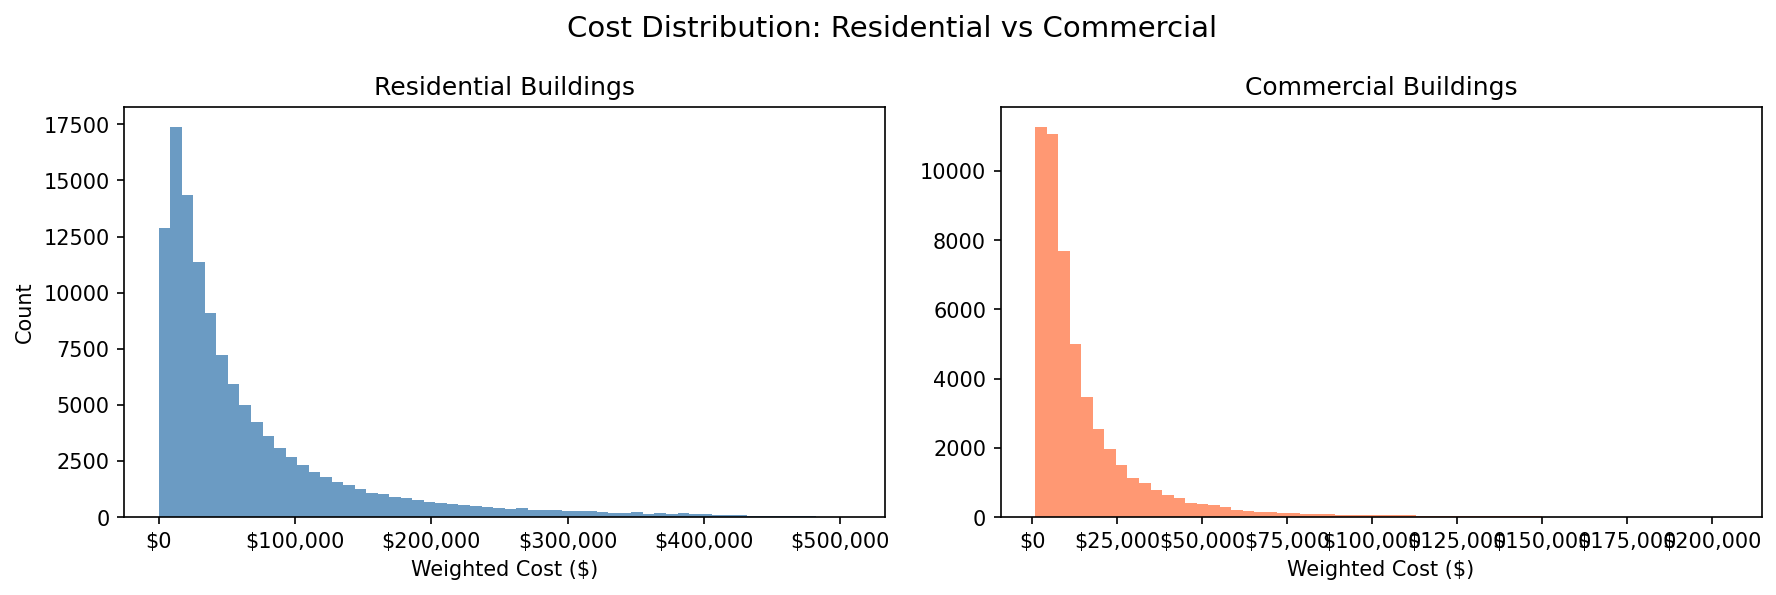

In [11]:
# Visualize cost distribution by building type
residential = results[results['residential'] == 1]
commercial = results[results['residential'] == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Cost Distribution: Residential vs Commercial', fontsize=14)

ax1.hist(residential['weighted_cost'], bins=60, color='steelblue', alpha=0.8)
ax1.set_title('Residential Buildings')
ax1.set_xlabel('Weighted Cost ($)')
ax1.set_ylabel('Count')
ax1.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

ax2.hist(commercial['weighted_cost'], bins=60, color='coral', alpha=0.8)
ax2.set_title('Commercial Buildings')
ax2.set_xlabel('Weighted Cost ($)')
ax2.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

### 3. Panel Upgrade Cost Distribution

Represents the variation in electrical panel upgrade costs based on building type and regional factors.

In [12]:
# Analyze how costs vary within building types
print("\n" + "="*70)
print("COST VARIATION WITHIN BUILDING TYPES")
print("="*70)

# For residential buildings
res_with_costs = residential[residential['weighted_cost'] > 0]
res_without_costs = residential[residential['weighted_cost'] == 0]

print(f"\nResidential Buildings:")
print(f"  With upgrades: {len(res_with_costs):,} ({len(res_with_costs)/len(residential)*100:.1f}%)")
print(f"  Without upgrades: {len(res_without_costs):,} ({len(res_without_costs)/len(residential)*100:.1f}%)")

if len(res_with_costs) > 0:
    print(f"\n  Buildings with upgrades - Cost distribution:")
    print(f"    Mean: ${res_with_costs['weighted_cost'].mean():,.0f}")
    print(f"    Median: ${res_with_costs['weighted_cost'].median():,.0f}")
    print(f"    Range: ${res_with_costs['weighted_cost'].min():,.0f} to ${res_with_costs['weighted_cost'].max():,.0f}")

# For commercial buildings
com_with_costs = commercial[commercial['weighted_cost'] > 0]
com_without_costs = commercial[commercial['weighted_cost'] == 0]

print(f"\nCommercial Buildings:")
print(f"  With upgrades: {len(com_with_costs):,} ({len(com_with_costs)/len(commercial)*100:.1f}%)")
print(f"  Without upgrades: {len(com_without_costs):,} ({len(com_without_costs)/len(commercial)*100:.1f}%)")

if len(com_with_costs) > 0:
    print(f"\n  Buildings with upgrades - Cost distribution:")
    print(f"    Mean: ${com_with_costs['weighted_cost'].mean():,.0f}")
    print(f"    Median: ${com_with_costs['weighted_cost'].median():,.0f}")
    print(f"    Range: ${com_with_costs['weighted_cost'].min():,.0f} to ${com_with_costs['weighted_cost'].max():,.0f}")


COST VARIATION WITHIN BUILDING TYPES

Residential Buildings:
  With upgrades: 120,337 (21.9%)
  Without upgrades: 0 (0.0%)

  Buildings with upgrades - Cost distribution:
    Mean: $65,346
    Median: $37,616
    Range: $99 to $507,533

Commercial Buildings:
  With upgrades: 51,964 (15.5%)
  Without upgrades: 0 (0.0%)

  Buildings with upgrades - Cost distribution:
    Mean: $15,726
    Median: $9,141
    Range: $924 to $204,372


## Cost Uncertainty Ranges

Let's explore the range of possible total costs due to distribution variability.

In [13]:
# Analyze which buildings drive costs
buildings_with_upgrades = results[results['weighted_cost'] > 0]

print("\n" + "="*70)
print("BUILDINGS DRIVING UPGRADE COSTS")
print("="*70)

print(f"\nTotal buildings analyzed: {len(results):,}")
print(f"Buildings requiring upgrades: {len(buildings_with_upgrades):,} ({len(buildings_with_upgrades)/len(results)*100:.1f}%)")
print(f"\nTotal upgrade costs: ${results['weighted_cost'].sum():,.0f}")
print(f"Cost per building (all): ${results['weighted_cost'].mean():,.0f}")
print(f"Cost per building (with upgrades): ${buildings_with_upgrades['weighted_cost'].mean():,.0f}")

# Top cost buildings
top_10_pct = results.nlargest(int(len(results) * 0.10), 'weighted_cost')
top_10_pct_cost = top_10_pct['weighted_cost'].sum()
print(f"\nTop 10% of buildings:")
print(f"  Count: {len(top_10_pct):,}")
print(f"  Total cost: ${top_10_pct_cost:,.0f}")
print(f"  Percentage of total: {top_10_pct_cost/results['weighted_cost'].sum()*100:.1f}%")


BUILDINGS DRIVING UPGRADE COSTS

Total buildings analyzed: 884,596
Buildings requiring upgrades: 172,301 (19.5%)

Total upgrade costs: $8,680,754,999
Cost per building (all): $50,381
Cost per building (with upgrades): $50,381



Top 10% of buildings:
  Count: 88,459
  Total cost: $7,798,163,525
  Percentage of total: 89.8%


## Understanding Cost Variation

Let's analyze how costs vary across buildings and what factors drive variation.

In [14]:
# Analyze state-level cost variation
print("\n" + "="*70)
print("STATE-LEVEL COST VARIATION")
print("="*70)

state_costs = results.groupby('state')['weighted_cost'].agg(['count', 'sum', 'mean', 'std', 'min', 'max'])
state_costs = state_costs.sort_values('sum', ascending=False)

print("\nTop 10 States by Total Cost:")
print(f"{'State':<5} {'Buildings':>12} {'Total Cost':>20} {'Mean Cost':>15} {'Std Dev':>15}")
print("-" * 70)
for state, row in state_costs.head(10).iterrows():
    print(f"{state:<5} {row['count']:>12,.0f} ${row['sum']:>18,.0f} ${row['mean']:>13,.0f} ${row['std']:>13,.0f}")


STATE-LEVEL COST VARIATION

Top 10 States by Total Cost:
State    Buildings           Total Cost       Mean Cost         Std Dev
----------------------------------------------------------------------
CA          19,377 $     1,101,198,541 $       56,830 $       75,853
TX          11,467 $       488,829,409 $       42,629 $       60,242
MI           9,889 $       474,937,456 $       48,027 $       64,287
NY           6,790 $       419,436,561 $       61,773 $       79,293
IL           6,740 $       378,945,830 $       56,223 $       73,308
FL           6,881 $       338,418,633 $       49,182 $       68,854
OH           7,084 $       323,980,389 $       45,734 $       63,009
PA           6,003 $       320,610,623 $       53,408 $       71,166
NC           6,176 $       284,306,628 $       46,034 $       63,000
NJ           5,032 $       265,518,911 $       52,766 $       69,317


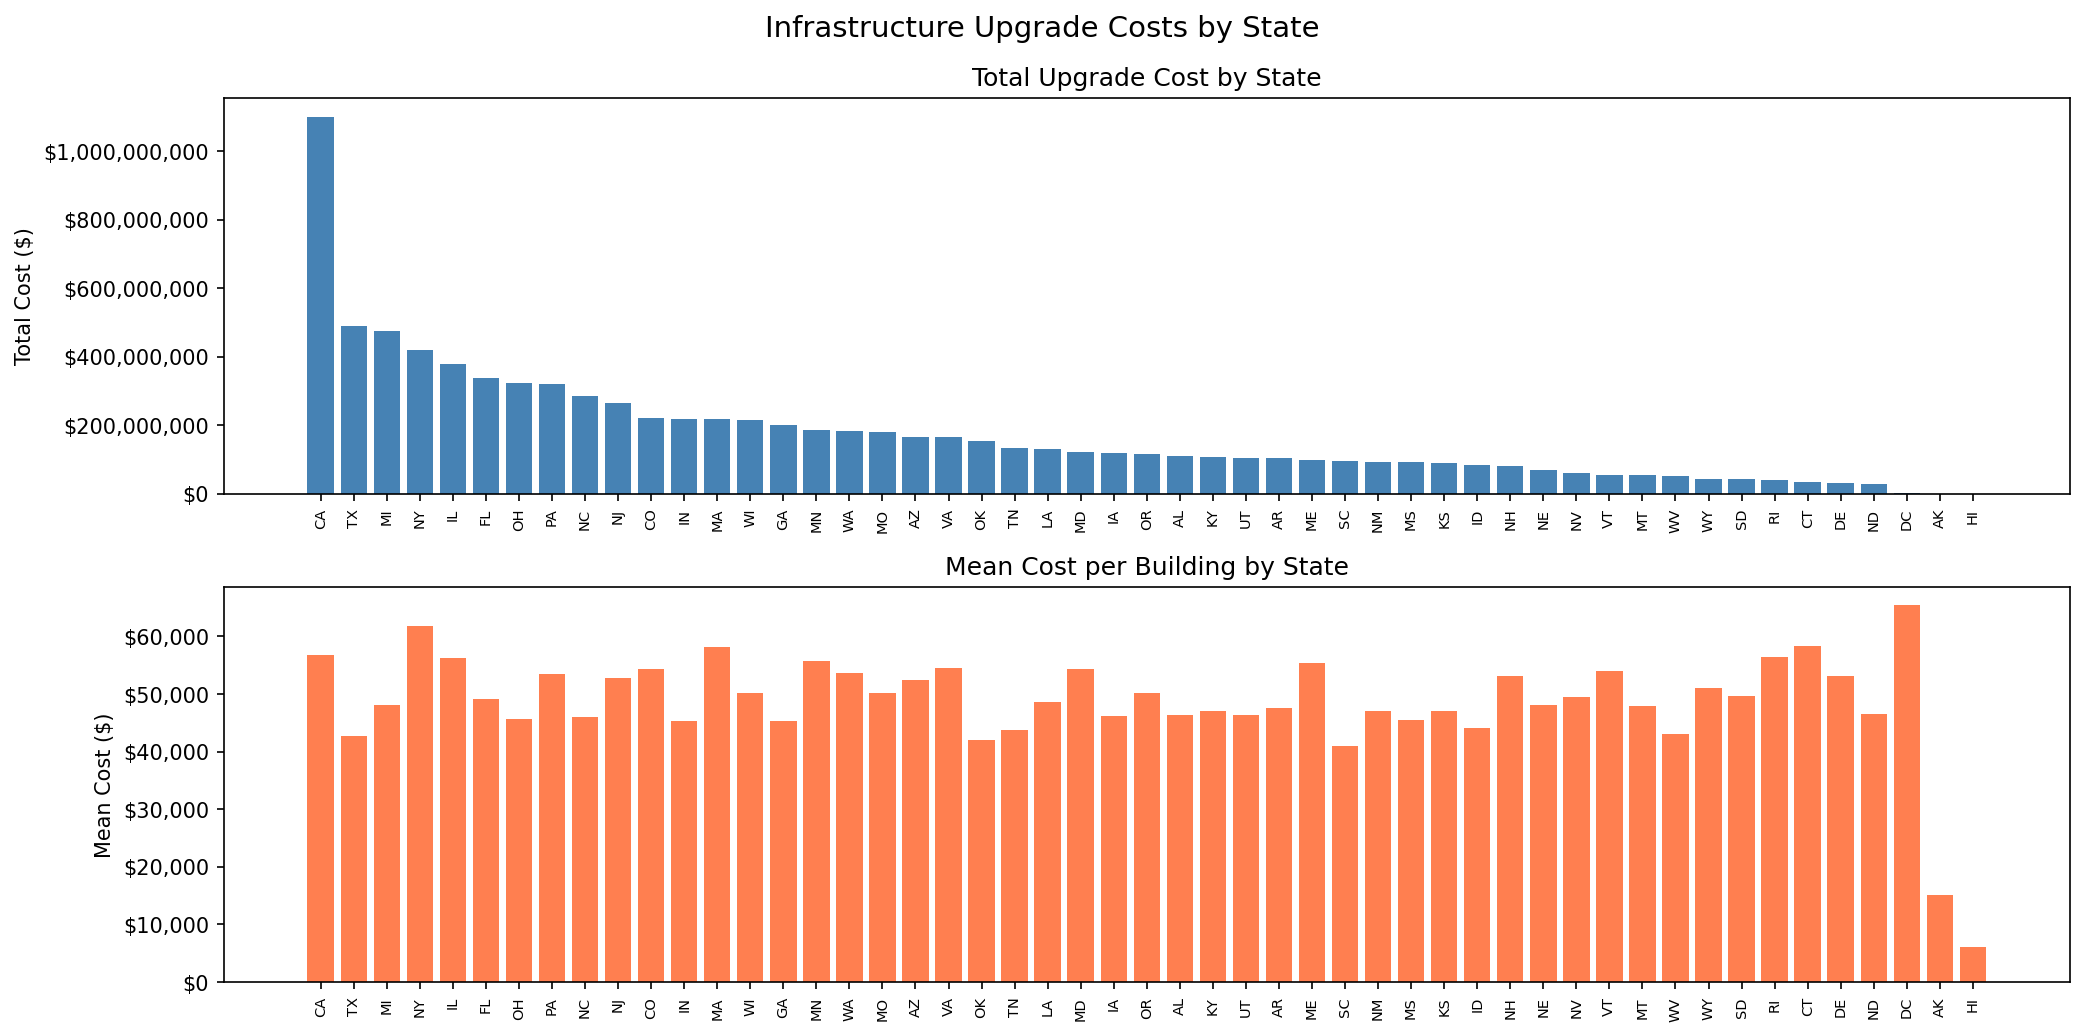

In [15]:
# Visualize state-level cost variation
state_stats = results.groupby('state').agg(
    total_cost=('weighted_cost', 'sum'),
    mean_cost=('weighted_cost', 'mean'),
    building_count=('weighted_cost', 'count')
).sort_values('total_cost', ascending=False)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle('Infrastructure Upgrade Costs by State', fontsize=14)

ax1.bar(state_stats.index, state_stats['total_cost'], color='steelblue')
ax1.set_ylabel('Total Cost ($)')
ax1.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax1.set_title('Total Upgrade Cost by State')
ax1.tick_params(axis='x', rotation=90, labelsize=7)

ax2.bar(state_stats.index, state_stats['mean_cost'], color='coral')
ax2.set_ylabel('Mean Cost ($)')
ax2.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax2.set_title('Mean Cost per Building by State')
ax2.tick_params(axis='x', rotation=90, labelsize=7)

plt.tight_layout()
plt.show()

In [16]:
# Analyze cost variation patterns
print("\n" + "="*70)
print("COST VARIATION PATTERNS")
print("="*70)

# Distribution shape analysis
print("\nDistribution characteristics:")
print(f"  Skewness: {stats.skew(results['weighted_cost']):.2f}")
print(f"    (Positive = right-skewed: many low costs, few high costs)")

print(f"\n  Kurtosis: {stats.kurtosis(results['weighted_cost']):.2f}")
print(f"    (Measures tail heaviness)")

# Compare distribution shapes by state
print("\nCost variation by state (top 5 states):")
for state in state_costs.head(5).index:
    state_data = results[results['state'] == state]['weighted_cost']
    print(f"\n  {state}:")
    print(f"    Mean: ${state_data.mean():,.0f}")
    print(f"    Median: ${state_data.median():,.0f}")
    print(f"    Skewness: {stats.skew(state_data):.2f}")
    print(f"    Coefficient of variation: {state_data.std()/state_data.mean():.2f}")


COST VARIATION PATTERNS

Distribution characteristics:
  Skewness: nan
    (Positive = right-skewed: many low costs, few high costs)

  Kurtosis: nan
    (Measures tail heaviness)

Cost variation by state (top 5 states):

  CA:
    Mean: $56,830
    Median: $28,006
    Skewness: nan
    Coefficient of variation: 1.33

  TX:
    Mean: $42,629
    Median: $19,489
    Skewness: nan
    Coefficient of variation: 1.41

  MI:
    Mean: $48,027
    Median: $23,776
    Skewness: nan
    Coefficient of variation: 1.34

  NY:
    Mean: $61,773
    Median: $31,804
    Skewness: nan
    Coefficient of variation: 1.28

  IL:
    Mean: $56,223
    Median: $28,021
    Skewness: nan
    Coefficient of variation: 1.30


## Cost Drivers and Distributions

In [17]:
# Analyze cost drivers by examining upgrade requirements
print("\n" + "="*70)
print("COST DRIVERS: UPGRADE REQUIREMENTS BY TECHNOLOGY")
print("="*70)

# Buildings with different capacity requirements
buildings_with_costs = results[results['weighted_cost'] > 0]

# Analyze required capacities that drive upgrades
print(f"\nAmong {len(buildings_with_costs):,} buildings needing upgrades:")

# Check which have positive max_elec_consumption_kwh
high_consumption = buildings_with_costs[buildings_with_costs['max_elec_consumption_kwh'] > 0]
print(f"  High electrical consumption: {len(high_consumption):,} ({len(high_consumption)/len(buildings_with_costs)*100:.1f}%)")

# Average consumption for buildings with/without costs
avg_consumption_all = results['max_elec_consumption_kwh'].mean()
avg_consumption_upgraded = buildings_with_costs['max_elec_consumption_kwh'].mean()

print(f"\nAverage Max Electrical Consumption:")
print(f"  All buildings: {avg_consumption_all:,.0f} kWh/year")
print(f"  Buildings needing upgrades: {avg_consumption_upgraded:,.0f} kWh/year")

# Cost relationship with building size
print(f"\nCost Correlation with Building Size (sqft):")
correlation = results['sqft'].corr(results['weighted_cost'])
print(f"  Correlation coefficient: {correlation:.3f}")
print(f"  (Positive = larger buildings tend to have higher costs)")


COST DRIVERS: UPGRADE REQUIREMENTS BY TECHNOLOGY



Among 172,301 buildings needing upgrades:
  High electrical consumption: 172,301 (100.0%)

Average Max Electrical Consumption:
  All buildings: 23 kWh/year
  Buildings needing upgrades: 15 kWh/year

Cost Correlation with Building Size (sqft):
  Correlation coefficient: -0.164
  (Positive = larger buildings tend to have higher costs)


## Designing Custom Distributions

If you need to use custom cost distributions, consider these approaches.

In [18]:
# Example: Creating a custom cost distribution

print("\n" + "="*70)
print("CREATING CUSTOM COST DISTRIBUTIONS")
print("="*70)

# Approach 1: Empirical Distribution (from your data)
def create_empirical_distribution(cost_data):
    """
    Create an empirical distribution from observed cost data.
    
    Args:
        cost_data: array of observed costs (non-zero values)
    
    Returns:
        A function that samples from the empirical distribution
    """
    # Filter to non-zero costs to match BICEP approach
    non_zero_costs = cost_data[cost_data > 0].values
    sorted_costs = np.sort(non_zero_costs)
    
    def sample(n=1):
        return np.random.choice(sorted_costs, size=n, replace=True)
    
    return sample, sorted_costs

# Create empirical distribution from actual residential data
res_empirical, res_costs_sorted = create_empirical_distribution(residential['weighted_cost'])

print(f"\nApproach 1: Empirical Distribution")
print(f"  Created from {len(res_costs_sorted):,} buildings with costs")
print(f"  Sample from distribution (10 buildings):")
samples = res_empirical(10)
for i, cost in enumerate(samples, 1):
    print(f"    Building {i}: ${cost:,.0f}")

# Approach 2: Parametric Distribution (log-normal)
def create_lognormal_distribution(data, min_val=0, max_val=np.inf):
    """
    Create a log-normal distribution fitted to cost data.
    
    Log-normal distributions are common for costs (always positive, right-skewed).
    
    Args:
        data: array of observed costs (non-zero)
        min_val: minimum cost (constrain)
        max_val: maximum cost (constrain)
    
    Returns:
        A function that samples from the distribution and fit parameters
    """
    non_zero = data[data > 0]
    # Fit log-normal to the data
    params = stats.lognorm.fit(non_zero)
    
    def sample(n=1):
        # Use scipy rvs to sample correctly with fitted parameters
        samples = stats.lognorm.rvs(*params, size=n)
        samples = np.clip(samples, min_val, max_val)
        return samples
    
    return sample, params

# Create log-normal distribution from actual residential data
res_lognormal, params = create_lognormal_distribution(residential['weighted_cost'])

print(f"\nApproach 2: Log-Normal Distribution")
print(f"  Fitted to actual residential data")
print(f"  Sample from distribution (10 buildings):")
samples = res_lognormal(10)
for i, cost in enumerate(samples, 1):
    print(f"    Building {i}: ${cost:,.0f}")



CREATING CUSTOM COST DISTRIBUTIONS

Approach 1: Empirical Distribution
  Created from 120,337 buildings with costs
  Sample from distribution (10 buildings):
    Building 1: $29,622
    Building 2: $5,977
    Building 3: $23,903
    Building 4: $45,837
    Building 5: $3,003
    Building 6: $31,742
    Building 7: $19,559
    Building 8: $261,113
    Building 9: $3,074
    Building 10: $5,369

Approach 2: Log-Normal Distribution
  Fitted to actual residential data
  Sample from distribution (10 buildings):
    Building 1: $203,911
    Building 2: $27,239
    Building 3: $49,526
    Building 4: $12,689
    Building 5: $169,177
    Building 6: $10,806
    Building 7: $38,707
    Building 8: $13,827
    Building 9: $68,260
    Building 10: $31,952


In [19]:
# Compare default vs custom distributions

print("\n" + "="*70)
print("COMPARING DISTRIBUTION APPROACHES")
print("="*70)

# Generate samples from both approaches
empirical_samples = res_empirical(5000)
lognormal_samples = res_lognormal(5000)
actual_data = residential[residential['weighted_cost'] > 0]['weighted_cost'].values

print(f"\nStatistics Comparison:")
print(f"{'Metric':<12} {'Actual Data':>15} {'Empirical':>15} {'Log-Normal':>15}")
print("-" * 57)
for label, a, e, l in [
    ('Mean', np.mean(actual_data), np.mean(empirical_samples), np.mean(lognormal_samples)),
    ('Median', np.median(actual_data), np.median(empirical_samples), np.median(lognormal_samples)),
    ('Std Dev', np.std(actual_data), np.std(empirical_samples), np.std(lognormal_samples)),
    ('Min', np.min(actual_data), np.min(empirical_samples), np.min(lognormal_samples)),
    ('Max', np.max(actual_data), np.max(empirical_samples), np.max(lognormal_samples)),
]:
    print(f"{label:<12} {f'${a:,.0f}':>15} {f'${e:,.0f}':>15} {f'${l:,.0f}':>15}")



COMPARING DISTRIBUTION APPROACHES

Statistics Comparison:
Metric           Actual Data       Empirical      Log-Normal
---------------------------------------------------------
Mean                 $65,346         $65,677         $67,845
Median               $37,616         $37,909         $36,882
Std Dev              $75,624         $76,043        $113,641
Min                      $99            $639            $305
Max                 $507,533        $485,064      $2,618,273


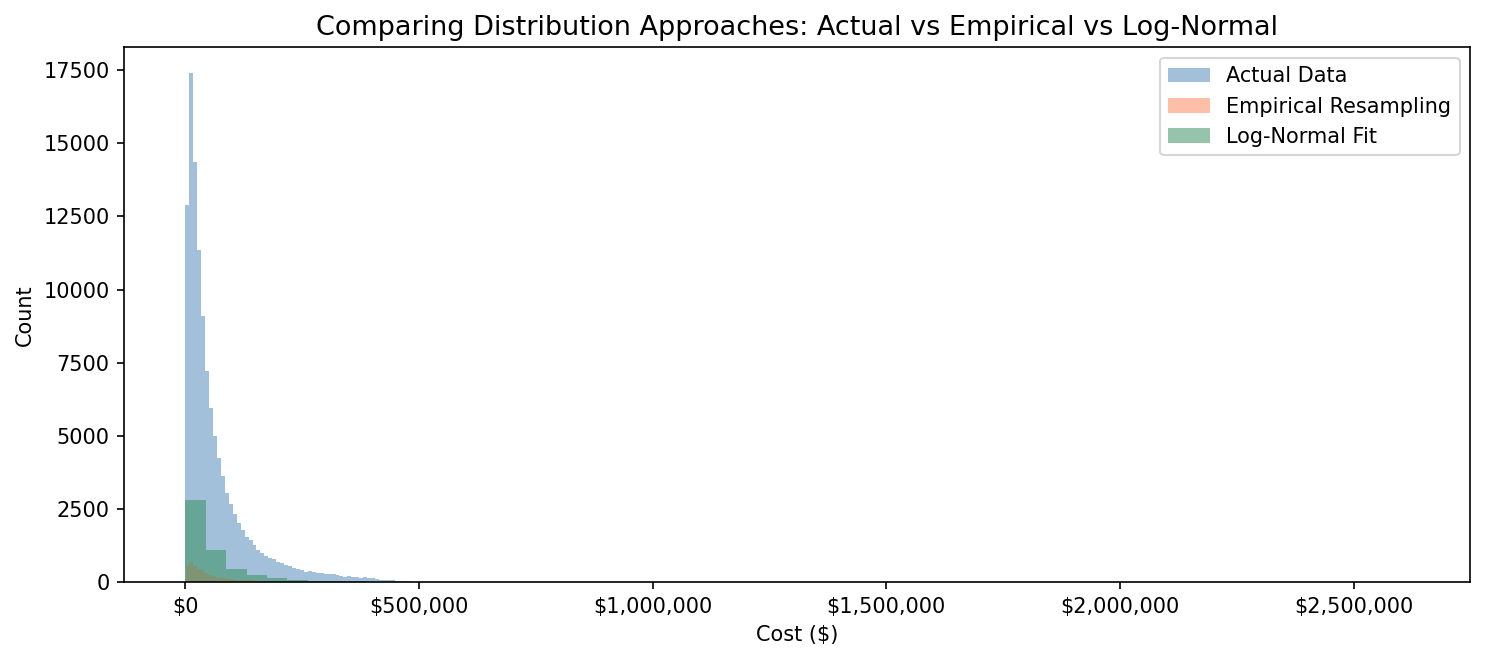

In [20]:
# Visualize: Actual vs Empirical vs Lognormal distributions
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.hist(actual_data, bins=60, alpha=0.5, color='steelblue', label='Actual Data')
ax.hist(empirical_samples, bins=60, alpha=0.5, color='coral', label='Empirical Resampling')
ax.hist(lognormal_samples, bins=60, alpha=0.5, color='seagreen', label='Log-Normal Fit')

ax.set_title('Comparing Distribution Approaches: Actual vs Empirical vs Log-Normal', fontsize=13)
ax.set_xlabel('Cost ($)')
ax.set_ylabel('Count')
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Impact of Distribution Choice on Total Costs

Different distributions can lead to significantly different total cost estimates.

In [21]:
# Impact of distribution choice on total costs

print("\n" + "="*70)
print("IMPACT OF DISTRIBUTION CHOICE ON TOTAL COSTS")
print("="*70)

# Get the count of residential buildings needing upgrades
num_buildings_upgraded = len(res_with_costs)

# Calculate total costs with different distributions
actual_mean = actual_data.mean()
empirical_mean = empirical_samples.mean()
lognormal_mean = lognormal_samples.mean()

total_actual = actual_mean * num_buildings_upgraded
total_empirical = empirical_mean * num_buildings_upgraded
total_lognormal = lognormal_mean * num_buildings_upgraded

print(f"\nProjecting costs for {num_buildings_upgraded:,} residential buildings needing upgrades:")
print(f"\nUsing Actual Data Distribution:")
print(f"  Mean cost per building: ${actual_mean:,.0f}")
print(f"  Total estimated cost: ${total_actual:,.0f}")

print(f"\nUsing Empirical Distribution (resampling actual):")
print(f"  Mean cost per building: ${empirical_mean:,.0f}")
print(f"  Total estimated cost: ${total_empirical:,.0f}")

print(f"\nUsing Log-Normal Distribution (parametric fit):")
print(f"  Mean cost per building: ${lognormal_mean:,.0f}")
print(f"  Total estimated cost: ${total_lognormal:,.0f}")

# Calculate differences
empirical_diff = total_empirical - total_actual
lognormal_diff = total_lognormal - total_actual
empirical_pct = (empirical_diff / total_actual) * 100
lognormal_pct = (lognormal_diff / total_actual) * 100

print(f"\nDifferences from actual data:")
print(f"  Empirical: ${empirical_diff:+,.0f} ({empirical_pct:+.1f}%)")
print(f"  Log-Normal: ${lognormal_diff:+,.0f} ({lognormal_pct:+.1f}%)")


IMPACT OF DISTRIBUTION CHOICE ON TOTAL COSTS

Projecting costs for 120,337 residential buildings needing upgrades:

Using Actual Data Distribution:
  Mean cost per building: $65,346
  Total estimated cost: $7,863,575,512

Using Empirical Distribution (resampling actual):
  Mean cost per building: $65,677
  Total estimated cost: $7,903,360,788

Using Log-Normal Distribution (parametric fit):
  Mean cost per building: $67,845
  Total estimated cost: $8,164,278,270

Differences from actual data:
  Empirical: $+39,785,276 (+0.5%)
  Log-Normal: $+300,702,758 (+3.8%)


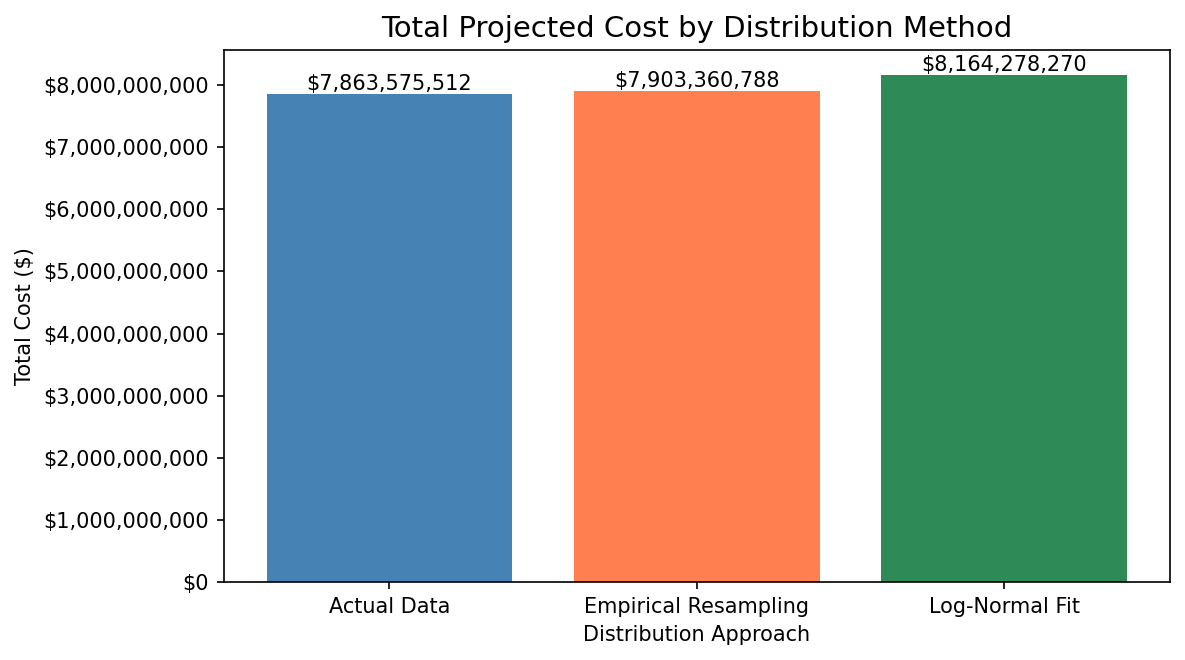

In [22]:
# Visualize impact of distribution choice on total cost estimates
dist_names = ['Actual Data', 'Empirical Resampling', 'Log-Normal Fit']
totals = [total_actual, total_empirical, total_lognormal]
colors = ['steelblue', 'coral', 'seagreen']

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(dist_names, totals, color=colors)
for bar, total in zip(bars, totals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'${total:,.0f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Total Projected Cost by Distribution Method', fontsize=14)
ax.set_ylabel('Total Cost ($)')
ax.set_xlabel('Distribution Approach')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.tight_layout()
plt.show()

## Key Takeaways

1. **Distributions capture uncertainty**: Costs aren't fixed; they vary based on many factors
2. **Distribution choice matters**: Different assumptions lead to significantly different estimates
3. **BICEP uses empirical and parametric distributions**: Based on real cost data and expert judgment
4. **Customization is possible**: You can implement your own distributions if needed
5. **Sensitivity analysis is important**: Test how results change with different cost assumptions

## Next Steps

- Review [Data Requirements](data-requirements.html) to understand technology adoption patterns
- Check [Scenario Comparison](scenario-comparison.html) for cost implications across scenarios
- Consult the [API Reference](../api-reference.html) for distribution class documentation